# Estimación de Edad mediante Visión Artificial

## Contenido

1. Introducción
2. Importación de librerías
3. Carga de los datos
4. Análisis exploratorio de datos
5. Construcción del modelo
6. El resultado
7. Conclusiones

## 1. Introducción

Problema de negocio

Una cadena de supermercados desea implementar un sistema de visión artificial capaz de estimar la edad aproximada de los clientes a partir de fotografías.

Contar con esta información permitirá verificar automáticamente la edad en la venta de productos con restricción, además de generar estadísticas demográficas que apoyen la toma de decisiones comerciales.

En este proyecto se desarrolla un modelo de Deep Learning utilizando TensorFlow/Keras para estimar la edad de una persona a partir de imágenes faciales. Para ello se realiza la exploración del conjunto de datos, el preprocesamiento de las imágenes, el entrenamiento del modelo y la evaluación de su desempeño mediante el Error Absoluto Medio (MAE).

## Objetivos

- Explorar el conjunto de datos de imágenes y comprender sus principales características.
- Preparar las imágenes para el entrenamiento del modelo.
- Construir un modelo de visión artificial utilizando TensorFlow/Keras.
- Evaluar el desempeño del modelo mediante el Error Absoluto Medio (MAE).
- Analizar los resultados obtenidos para determinar si el modelo cumple con el objetivo del proyecto.

## 2. Importación de librerías

En esta sección se importan las librerías necesarias para el desarrollo del proyecto.

- **Pandas:** utilizado para cargar y manipular la información del conjunto de datos.
- **Matplotlib:** empleado para la visualización y exploración de los datos.
- **ImageDataGenerator (TensorFlow/Keras):** utilizado para cargar y preparar las imágenes, aplicando el preprocesamiento necesario para el entrenamiento y validación del modelo de visión artificial.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### Hallazgos principales

- Se importaron las librerías necesarias para el análisis y el desarrollo del modelo.
- TensorFlow/Keras proporciona las herramientas necesarias para construir, entrenar y evaluar el modelo de visión artificial.

## 3. Carga de los datos

En esta sección se carga el archivo `labels.csv`, el cual contiene la información asociada a cada imagen del conjunto de datos. Posteriormente, se revisa la estructura del dataset, los tipos de datos, las estadísticas descriptivas de la variable objetivo (`real_age`) y la existencia de nombres de archivo duplicados.

Debido al elevado número de imágenes del conjunto de datos, estas no se cargan directamente en memoria. En su lugar, se utilizará `ImageDataGenerator` para leerlas por lotes durante el entrenamiento del modelo.

In [ ]:
labels = pd.read_csv('/datasets/faces/labels.csv')

In [ ]:
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


In [ ]:
labels.head()

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


In [ ]:
labels.describe()

,real_age
count,7591.000000
mean,31.201159
std,17.145060
min,1.000000
25%,20.000000
50%,29.000000
75%,41.000000
max,100.000000


In [ ]:
labels['file_name'].duplicated().sum()

0

### Hallazgos principales

- El conjunto de datos contiene **7,591 registros**, cada uno asociado a una imagen facial.
- El dataset no presenta valores faltantes en las columnas **file_name** y **real_age**.
- La edad de los participantes varía entre **1 y 100 años**, con una media aproximada de **31 años**.
- No se identificaron nombres de archivo duplicados, por lo que cada imagen corresponde a un único registro.
- El archivo **labels.csv** proporciona la información necesaria para relacionar cada imagen con la edad real del individuo.

## 4. Análisis exploratorio de datos (EDA)

En esta sección se explora el conjunto de datos mediante estadísticas descriptivas y visualizaciones, con el objetivo de comprender la distribución de las edades y verificar la calidad de las imágenes antes del entrenamiento del modelo de visión artificial. Este análisis permite identificar posibles desbalances en los datos y evaluar si el conjunto de imágenes es adecuado para la tarea de estimación de edad.

### 4.1. Distribución de edades

Text(0, 0.5, 'Frecuencia')

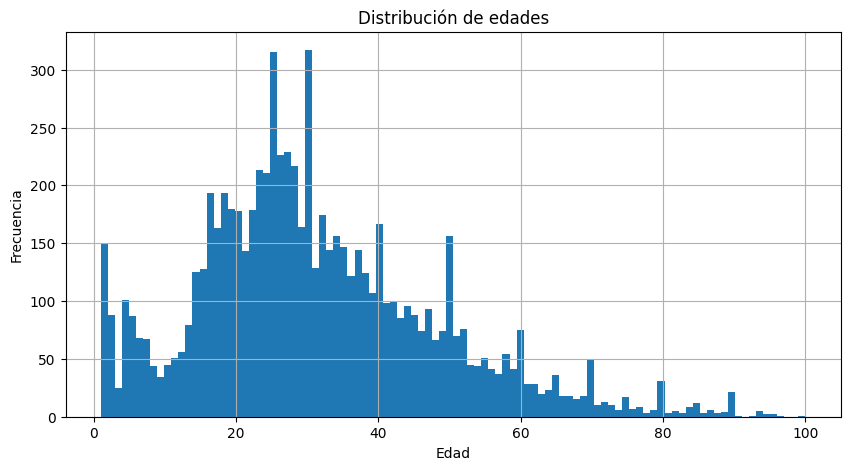

In [ ]:
plt.figure(figsize=(10,5))
labels['real_age'].hist(bins=100)
plt.title('Distribución de edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

### Hallazgos principales

- El conjunto de datos no presenta valores ausentes en la variable real_age.
- La distribución de edades no es uniforme.
- La mayor concentración de imágenes corresponde a personas jóvenes y adultas, principalmente entre los 18 y 35 años.
- A partir de los 40 años la cantidad de imágenes disminuye progresivamente y las personas mayores de 60 años están menos representadas.
- Este desbalance podría favorecer el aprendizaje del modelo en los rangos de edad con mayor número de ejemplos y generar una menor precisión en los grupos menos representados.

### 4.2. Visualización de imágenes

In [ ]:
datagen= ImageDataGenerator(rescale=1./255)

gen_flow = datagen.flow_from_dataframe(dataframe=labels, directory='/datasets/faces/final_files/', x_col='file_name', y_col='real_age', target_size=(224,224), batch_size=16, class_mode='raw', seed=12345)

Found 7591 validated image filenames.


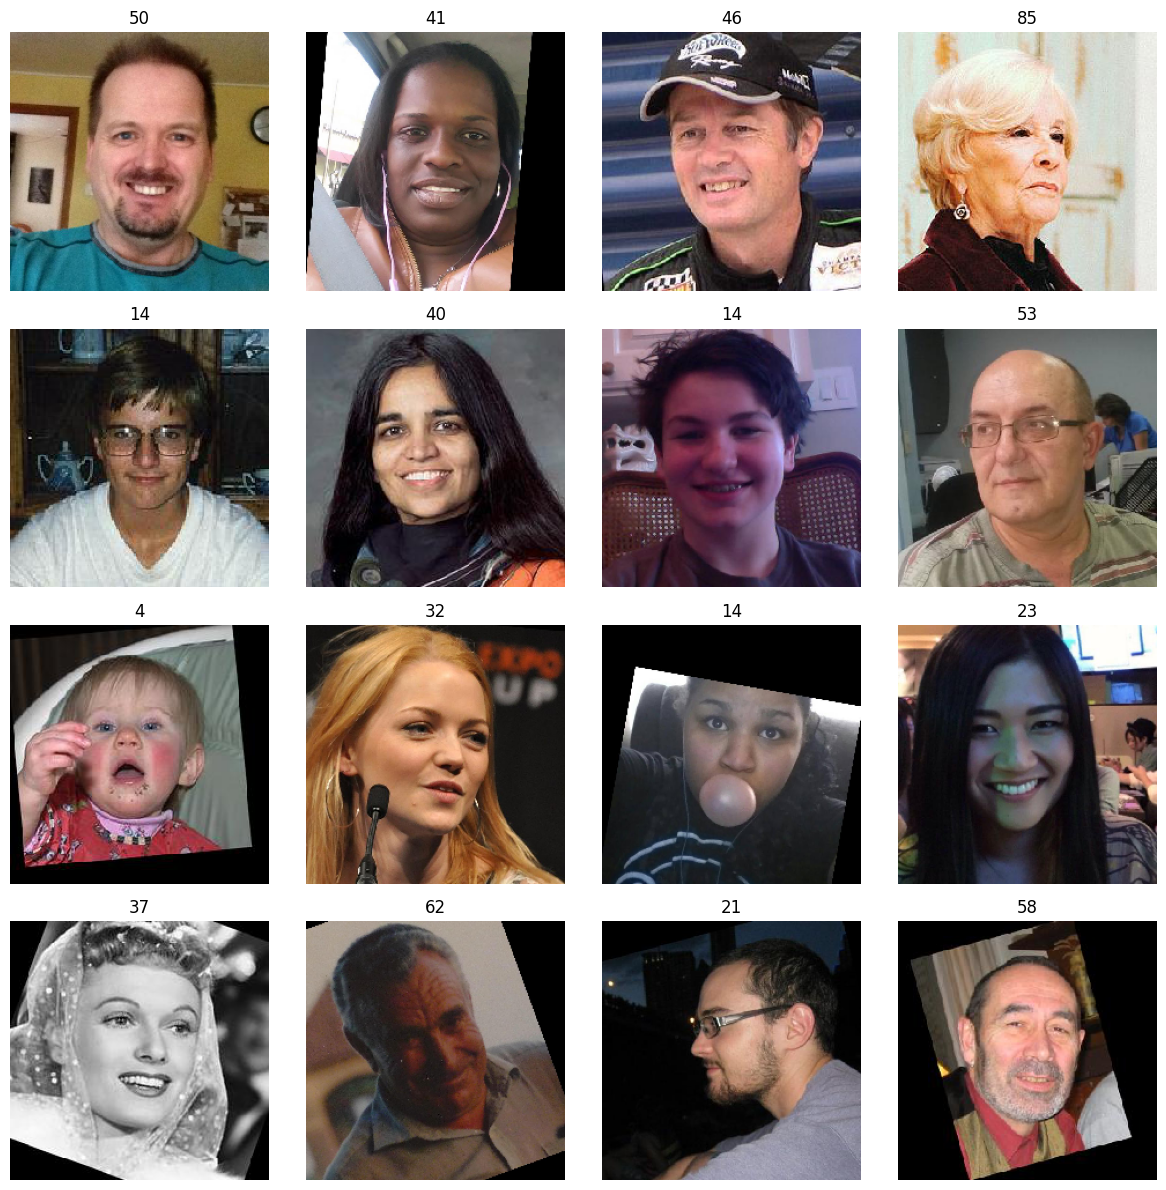

In [ ]:
features, target = next(gen_flow)

fig, axes = plt.subplots(4,4, figsize=(12,12))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(features[i])
    ax.set_title(int(target[i]))
    ax.axis('off')

plt.tight_layout()
plt.show()

### Hallazgos principales

- Las imágenes fueron cargadas correctamente mediante ImageDataGenerator.
- Todas las imágenes se redimensionan a 224 × 224 píxeles, lo que garantiza un tamaño uniforme para el entrenamiento del modelo.
- El conjunto de datos contiene fotografías de personas de diferentes edades, géneros y características físicas.
- La diversidad en las expresiones faciales, la iluminación y los fondos permitirá que el modelo aprenda a partir de condiciones similares a las que podría encontrar en escenarios reales.

### 4.3 Conclusión del análisis exploratorio

El análisis exploratorio mostró que el conjunto de datos presenta una distribución de edades desbalanceada, con mayor representación de personas jóvenes y adultas. Asimismo, la inspección visual confirmó que las imágenes fueron cargadas correctamente y presentan diversidad en las características de los individuos. Aunque algunos grupos de edad están menos representados, el conjunto de datos contiene una cantidad suficiente de ejemplos para entrenar un modelo de estimación de edad. Dado que el objetivo del proyecto es estimar la edad de los clientes para apoyar la verificación de la mayoría de edad en la venta de productos con restricción, la mayor concentración de imágenes de personas jóvenes y adultas constituye una ventaja para entrenar un modelo orientado a la estimación de edad.

## 5. Construcción del modelo

En esta sección se definen las funciones necesarias para cargar las imágenes, construir el modelo de Deep Learning y entrenarlo utilizando TensorFlow/Keras.

In [ ]:
import pandas as pd

import tensorflow as tf


from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

Primero se definen las funciones necesarias para preparar los datos, construir la arquitectura del modelo y realizar el entrenamiento.

In [ ]:
def load_train(path):
    """
    Carga la parte de entrenamiento del conjunto de datos desde la ruta.
    """

    labels = pd.read_csv(path + 'labels.csv')

    train_datagen = ImageDataGenerator(validation_split=0.25, rescale=1./255, horizontal_flip=True)

    train_gen_flow = train_datagen.flow_from_dataframe(dataframe=labels, directory=path + 'final_files/', x_col='file_name', y_col='real_age', target_size=(224, 224), batch_size=16, class_mode='raw', subset='training', seed=12345)   

    return train_gen_flow

### Hallazgos principales

- Se definió un generador para cargar las imágenes de entrenamiento mediante ImageDataGenerator.
- Se aplicó un reescalado de los valores de los píxeles al intervalo [0,1].
- Se utilizó una partición del 75% para entrenamiento y 25% para validación.
- Se incorporó aumento de datos mediante volteo horizontal (horizontal_flip) para mejorar la capacidad de generalización del modelo.

In [ ]:
def load_test(path):
    """
    Carga la parte de validación/prueba del conjunto de datos desde la ruta
    """
    labels = pd.read_csv(path + 'labels.csv')

    test_datagen = ImageDataGenerator(validation_split=0.25, rescale=1./255)

    test_gen_flow =test_datagen.flow_from_dataframe(dataframe=labels, directory=path + 'final_files/', x_col='file_name', y_col='real_age', target_size=(224, 224), batch_size=16, class_mode='raw', subset='validation', seed=12345)

    return test_gen_flow

### Hallazgos principales

- Se creó un generador independiente para el conjunto de validación.
- El conjunto de validación utiliza únicamente el reescalado de las imágenes, sin aplicar aumentos de datos.
- Esta configuración permite evaluar el desempeño del modelo sobre imágenes no modificadas.

In [ ]:

def create_model(input_shape):
    """
    Define el modelo
    """
    backbone = ResNet50(weights='imagenet', input_shape=input_shape, include_top=False)

    model = Sequential([backbone, GlobalAveragePooling2D(), Dense(1, activation='relu')])

    model.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])

    return model

### Hallazgos principales

- Se empleó ResNet50 preentrenada en ImageNet mediante aprendizaje por transferencia.
- Se añadió una capa GlobalAveragePooling2D seguida de una capa densa para realizar la estimación de la edad.
- El modelo fue optimizado utilizando Adam y el Error Absoluto Medio (MAE) como métrica principal.

In [ ]:
def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):
    """
    Entrena el modelo dados los parámetros
    """
   
    model.fit(train_data, validation_data=test_data, epochs=epochs, verbose=2)
    
    return model

### Hallazgos principales

- El entrenamiento se realizó utilizando los generadores de entrenamiento y validación.
- Durante el entrenamiento se monitoreó el desempeño del modelo mediante la pérdida y el MAE sobre ambos conjuntos.
- El modelo entrenado será utilizado para estimar la edad a partir de nuevas imágenes.

In [ ]:
train_data = load_train('/datasets/faces/')
test_data = load_test('/datasets/faces/')
model = create_model((224, 224, 3))
model = train_model(model, train_data, test_data) 
history= model.fit(train_data, validation_data=test_data, epochs=1, verbose=1)

Found 5694 validated image filenames.
Found 1897 validated image filenames.


2026-07-18 01:31:49.869262: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 6. Resultados del entrenamiento

A continuación se presentan los resultados obtenidos durante la ejecución del modelo utilizando la configuración definida en el proyecto.

**Salida del entrenamiento del modelo:**

Found 5694 validated image filenames.
Found 1897 validated image filenames.

712/712 - 618s - loss: 1303.8778 - mae: 31.7292 - val_loss: 1158.0159 - val_mae: 29.6162

### Hallazgos principales

- Se utilizaron 5,694 imágenes para entrenamiento y 1,897 imágenes para validación.
- El modelo completó el proceso de entrenamiento con la configuración implementada.
- Se obtuvo un MAE de aproximadamente 31.73 en entrenamiento y 29.62 en validación.
- El desempeño obtenido no alcanza el criterio esperado para el proyecto (MAE ≤ 8), por lo que existe margen para mejorar el modelo mediante ajustes en la arquitectura y los hiperparámetros.

## Conclusiones

El objetivo del proyecto fue desarrollar un modelo de visión artificial capaz de estimar la edad de una persona a partir de imágenes faciales mediante técnicas de Deep Learning.

Durante el desarrollo del proyecto se exploró el conjunto de datos, se prepararon las imágenes utilizando ImageDataGenerator y se implementó un modelo basado en ResNet50 mediante aprendizaje por transferencia.

El análisis exploratorio mostró que la distribución de edades no es uniforme, con una mayor representación de personas jóvenes y adultas, mientras que los grupos de menor y mayor edad cuentan con menos ejemplos. Este desbalance puede influir en la capacidad del modelo para generalizar correctamente en todos los rangos de edad.

El entrenamiento obtuvo un MAE aproximado de **29.62** años sobre el conjunto de validación, resultado que no cumple el criterio esperado para el proyecto (MAE ≤ 8). Esto indica que aún existe margen de mejora mediante el ajuste de hiperparámetros, un mayor número de épocas o técnicas adicionales de aumento de datos.

Finalmente, este proyecto permitió implementar un flujo completo de visión artificial utilizando TensorFlow/Keras y comprender las principales etapas involucradas en la construcción de modelos para la estimación de edad a partir de imágenes.